In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_log_error

In [9]:
data = np.random.rand(10)
print("Data:", data)

# 가우시안 정규분포를 의미한다.
data = np.random.randn(10)
print("Data:", data)

# 균열 분포의 정수 난수
data = np.random.randint(10)
print("Data:", data)


Data: [0.45123552 0.08394079 0.2074785  0.13436749 0.6523477  0.6218776
 0.61811173 0.48604797 0.13217783 0.927153  ]
Data: [ 0.94640912  1.73487705 -0.44371335 -0.65817929 -0.72014425  0.4414455
  0.89292799 -0.39388268  1.90234316  0.22743204]
Data: 2


In [11]:
print('np.random.shuffle')
# np.random.shuffle : 배열의 순서를 무작위로 섞는다. 원본 배열을 변경한다.
data = np.arange(10)
print("Original Data:", data)
np.random.shuffle(data)
print("Shuffled Data:", data)

np.random.shuffle
Original Data: [0 1 2 3 4 5 6 7 8 9]
Shuffled Data: [6 0 8 2 1 7 4 3 5 9]


In [13]:
print('np.random.permutation')
data = np.arange(10)
print("Original Data:", data)
permuted_data = np.random.permutation(data) 
print("Permuted Data:", permuted_data)

np.random.permutation
Original Data: [0 1 2 3 4 5 6 7 8 9]
Permuted Data: [0 5 9 8 1 7 3 4 2 6]


In [ ]:
# np.random.choice(a, size=None, replace=True, p=None) : 1차원 배열에서 임의의 샘플을 추출한다.
# a : 1차원 배열
# size : 추출할 샘플의 수
# replace : True이면 중복 허용, False이면 중복 불허
# p : 각 원소가 선택될 확률을 나타내는 1차원 배열

print(np.random.choice(5,5, replace=False)) # 0~4까지의 숫자 중에서 5개를 중복없이 랜덤하게 선택   
data = np.arange(10)
print(f"Original Data:", np.random.choice(data,5))

[3 1 4 2 0]
Original Data: [4 6 6 5 7]


#### 추세선(Trend Line)
- 추세선(Trend Line)은 데이터의 추세를 그래픽으로 표시하고 예측 문제를 분석하는데 사용된다.
- 이러한 분석을 회귀분석(예측을 위해 사용하는 통계분석의 한가지)이라고 하며,
회귀분석을 사용하여 실제 데이터가 존재하지 않는 범위의 값을 예측할 수 있다.
- 추세선을 사용할 수 있는 차트 : 누적형이 아닌 2차원 영역형, 가로 막대형, 세로 막대형, 꺾은선형, 주식형,분산형, 거품형
- 추세선을 사용할 수 없는 차트 : 3차원, 누적형, 방사형, 원형, 표면형, 도넛형

(100, 1)
(100, 1)
          X          y
0  0.877752  10.029189
1  0.041004   6.306636
2  0.658759   8.800627
3  0.919345   9.885640
4  1.464881  12.623914


<Axes: xlabel='X', ylabel='y'>

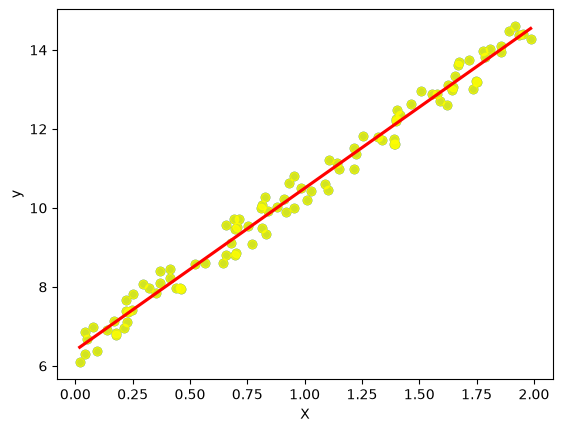

In [34]:
X = 2*np.random.rand(100,1)
print(X.shape)

y = 6 + 4*X + np.random.rand(100,1)
print(y.shape) 

plt.scatter(X,y)

pd_X= pd.DataFrame(X, columns=['X'])
pd_y= pd.DataFrame(y, columns=['y'])
pd_df = pd.concat([pd_X, pd_y], axis=1)

print(pd_df.head())

sns.regplot(data=pd_df, x='X', y='y', ci=None, line_kws={'color':'red'}, scatter_kws={'color':'yellow'})



### 경사 하강법(gradient_descent_steps) _MSE(평균제곱오차계산식)
- 경사하강법(Gradient Descent)은 함수의 손실(오차)을 최소화하기 위해 기울기(Gradient)가 낮은 방향으로 매개변수를 반복해서 업데이트하는 최적화 알고리즘
- 파라미터 (Parameter) :  스스로 학습하며 최적의 값을 찾아가는 변수 -w, b

- 하이퍼파라미터 (Hyperparameter) : 모델이 학습을 시작하기 전에, 사람(개발자)이 외부에서 직접 설정해 주는 값 - learning_rate, l1, l2

추정된 w: 3.770 (실제 정답: 4)
추정된 b: 6.215 (실제 정답: 6)
Gradient Descent Total Cost: 0.8066


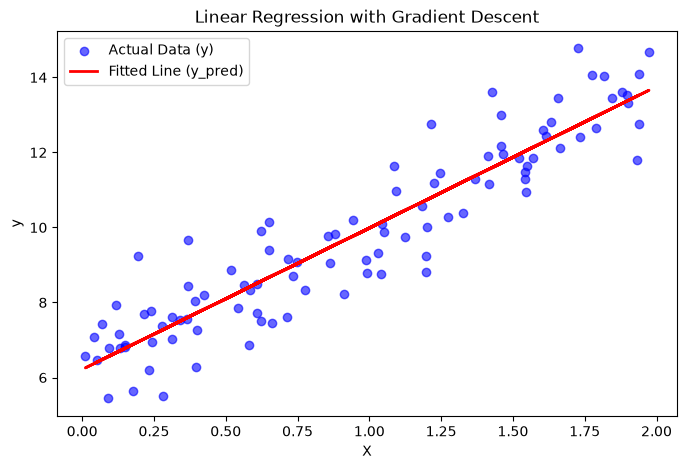

In [35]:
import numpy as np
import matplotlib.pyplot as plt

def get_weight_updates(w, b, X, y, learning_rate=0.01, l1=0.2, l2=0.7):
    N = len(y)  # 데이터 개수     
    
    # 1. 예측값 및 오차 계산
    y_pred = np.dot(X, w.T) + b   # 예측값: (N, 1)
    diff = y - y_pred             # 실제값 - 예측값: (N, 1)

    # 2. b_update를 dot행렬 연산으로 구하기 위해 모두 1값을 가진 행렬 생성
    b_factors = np.ones((N, 1))

    # 3. 기울기 방향 업데이트량 구하기 
    # (diff = y - y_pred 이므로 가중치를 오차 방향으로 '더해'주기 위한 + 값)
    w_update = (2 / N) * learning_rate * np.dot(X.T, diff)
    b_update = (2 / N) * learning_rate * np.dot(b_factors.T, diff)
    
    return w_update, b_update

# 입력 인자 epochs로 주어진 횟수만큼 반복적으로 w와 b를 업데이트함
def gradient_descent_steps(X, y, epochs=1000, learning_rate=0.1):
    # w와 b를 모두 0으로 초기화
    w = np.zeros((1, 1))
    b = np.zeros((1, 1))   # y = wX + b

    for ind in range(epochs):
        w_update, b_update = get_weight_updates(w, b, X, y, learning_rate=learning_rate)
        
        # [수정] 빼기(-)가 아닌 더하기(+)를 수행해야 오차가 줄어듭니다.
        w = w + w_update
        b = b + b_update
        
    return w, b

# MSE(평균제곱오차) 계산 함수
def get_cost(y, y_pred):
    N = len(y)
    cost = np.sum(np.square(y - y_pred)) / N
    return cost

# --------------------------------------------------
# 데이터 생성 및 실행
# --------------------------------------------------
np.random.seed(42)  # 재현성을 위한 난수 고정
X = 2 * np.random.rand(100, 1)
y = 6 + 4 * X + np.random.randn(100, 1)   # 실제 타깃: w=4, b=6

# 에포크를 1000으로 설정하여 충분히 수렴시킴
w, b = gradient_descent_steps(X, y, epochs=1000, learning_rate=0.05)

print(f'추정된 w: {w[0, 0]:.3f} (실제 정답: 4)')
print(f'추정된 b: {b[0, 0]:.3f} (실제 정답: 6)')

y_pred = w[0, 0] * X + b
print(f'Gradient Descent Total Cost: {get_cost(y, y_pred):.4f}')

# 시각화
plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Actual Data (y)', color='blue', alpha=0.6)
plt.plot(X, y_pred, label='Fitted Line (y_pred)', color='red', linewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression with Gradient Descent')
plt.legend()
plt.show()